In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ── Project Paths ──────────────────────────────────────────────────
DATA_DIR         = r"C:\Data Science\DS Projects\Health vs Wealth analysis"
CHART_DIR_WHO    = r"C:\Data Science\DS Projects\Health vs Wealth analysis\Charts\WHO"
CHART_DIR_MERGED = r"C:\Data Science\DS Projects\Health vs Wealth analysis\Charts\Merged"

WHO_FILE  = os.path.join(DATA_DIR, "Life_Expectancy_Data_1_CSV.csv")
GDP_FILE  = os.path.join(DATA_DIR, "GDP per capita main CSV.csv")
POP_FILE  = os.path.join(DATA_DIR, "Population main CSV.csv")

# ── Create folder structure ────────────────────────────────────────
os.makedirs(CHART_DIR_WHO,    exist_ok=True)
os.makedirs(CHART_DIR_MERGED, exist_ok=True)

# ── Load Data ──────────────────────────────────────────────────────
who    = pd.read_csv(WHO_FILE)
gdp_wb = pd.read_csv(GDP_FILE, skiprows=4)
pop_wb = pd.read_csv(POP_FILE, skiprows=4)

# ── Clean column names ─────────────────────────────────────────────
who.columns    = who.columns.str.strip()
gdp_wb.columns = gdp_wb.columns.str.strip()
pop_wb.columns = pop_wb.columns.str.strip()

# ── Reshape World Bank files from wide to long ─────────────────────
gdp_long = gdp_wb.melt(
    id_vars    = ['Country Name', 'Country Code'],
    value_vars = [str(y) for y in range(2000, 2016)],
    var_name   = 'Year',
    value_name = 'GDP_per_capita'
)
gdp_long['Year'] = gdp_long['Year'].astype(int)

pop_long = pop_wb.melt(
    id_vars    = ['Country Name', 'Country Code'],
    value_vars = [str(y) for y in range(2000, 2016)],
    var_name   = 'Year',
    value_name = 'Population'
)
pop_long['Year'] = pop_long['Year'].astype(int)

# ── Rename WHO countries to match World Bank naming ────────────────
who['Country'] = who['Country'].replace({
    'Bahamas'                                             : 'Bahamas, The',
    'Bolivia (Plurinational State of)'                    : 'Bolivia',
    'Congo'                                               : 'Congo, Rep.',
    'Democratic Republic of the Congo'                    : 'Congo, Dem. Rep.',
    "CÃ´te d'Ivoire"                                      : "Cote d'Ivoire",
    'Egypt'                                               : 'Egypt, Arab Rep.',
    'Gambia'                                              : 'Gambia, The',
    'Iran (Islamic Republic of)'                          : 'Iran, Islamic Rep.',
    'Kyrgyzstan'                                          : 'Kyrgyz Republic',
    "Lao People's Democratic Republic"                    : 'Lao PDR',
    'Micronesia (Federated States of)'                    : 'Micronesia, Fed. Sts.',
    'Republic of Korea'                                   : 'Korea, Rep.',
    'Republic of Moldova'                                 : 'Moldova',
    "Democratic People's Republic of Korea"               : "Korea, Dem. People's Rep.",
    'Slovakia'                                            : 'Slovak Republic',
    'Swaziland'                                           : 'Eswatini',
    'The former Yugoslav republic of Macedonia'           : 'North Macedonia',
    'Turkey'                                              : 'Turkiye',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'United Republic of Tanzania'                         : 'Tanzania',
    'United States of America'                            : 'United States',
    'Venezuela (Bolivarian Republic of)'                  : 'Venezuela, RB',
    'Yemen'                                               : 'Yemen, Rep.'
})

# ── Build country code lookup and merge into WHO ───────────────────
lookup   = gdp_long[['Country Name', 'Country Code']].drop_duplicates()
who      = pd.merge(who, lookup, left_on='Country', right_on='Country Name', how='left')

# ── Merge GDP and Population into WHO ─────────────────────────────
who = pd.merge(who,
               gdp_long[['Country Code', 'Year', 'GDP_per_capita']],
               on=['Country Code', 'Year'], how='left')

who = pd.merge(who,
               pop_long[['Country Code', 'Year', 'Population']],
               on=['Country Code', 'Year'], how='left')

# ── Drop unreliable columns and rename ────────────────────────────
who = who.drop(columns=['GDP', 'Population_x', 'Country Name'])
who = who.rename(columns={'Population_y': 'Population'})

# ── Add Region mapping ─────────────────────────────────────────────
region_map = {
    'Angola':'Sub-Saharan Africa','Benin':'Sub-Saharan Africa',
    'Botswana':'Sub-Saharan Africa','Burkina Faso':'Sub-Saharan Africa',
    'Burundi':'Sub-Saharan Africa','Cabo Verde':'Sub-Saharan Africa',
    'Cameroon':'Sub-Saharan Africa','Central African Republic':'Sub-Saharan Africa',
    'Chad':'Sub-Saharan Africa','Comoros':'Sub-Saharan Africa',
    'Congo, Dem. Rep.':'Sub-Saharan Africa','Congo, Rep.':'Sub-Saharan Africa',
    "Cote d'Ivoire":'Sub-Saharan Africa','Djibouti':'Sub-Saharan Africa',
    'Equatorial Guinea':'Sub-Saharan Africa','Eritrea':'Sub-Saharan Africa',
    'Eswatini':'Sub-Saharan Africa','Ethiopia':'Sub-Saharan Africa',
    'Gabon':'Sub-Saharan Africa','Gambia, The':'Sub-Saharan Africa',
    'Ghana':'Sub-Saharan Africa','Guinea':'Sub-Saharan Africa',
    'Guinea-Bissau':'Sub-Saharan Africa','Kenya':'Sub-Saharan Africa',
    'Lesotho':'Sub-Saharan Africa','Liberia':'Sub-Saharan Africa',
    'Madagascar':'Sub-Saharan Africa','Malawi':'Sub-Saharan Africa',
    'Mali':'Sub-Saharan Africa','Mauritania':'Sub-Saharan Africa',
    'Mauritius':'Sub-Saharan Africa','Mozambique':'Sub-Saharan Africa',
    'Namibia':'Sub-Saharan Africa','Niger':'Sub-Saharan Africa',
    'Nigeria':'Sub-Saharan Africa','Rwanda':'Sub-Saharan Africa',
    'Sao Tome and Principe':'Sub-Saharan Africa','Senegal':'Sub-Saharan Africa',
    'Seychelles':'Sub-Saharan Africa','Sierra Leone':'Sub-Saharan Africa',
    'Somalia':'Sub-Saharan Africa','South Africa':'Sub-Saharan Africa',
    'South Sudan':'Sub-Saharan Africa','Sudan':'Sub-Saharan Africa',
    'Tanzania':'Sub-Saharan Africa','Togo':'Sub-Saharan Africa',
    'Uganda':'Sub-Saharan Africa','Zambia':'Sub-Saharan Africa',
    'Zimbabwe':'Sub-Saharan Africa',
    'Algeria':'North Africa & Middle East','Bahrain':'North Africa & Middle East',
    'Egypt, Arab Rep.':'North Africa & Middle East','Iran, Islamic Rep.':'North Africa & Middle East',
    'Iraq':'North Africa & Middle East','Jordan':'North Africa & Middle East',
    'Kuwait':'North Africa & Middle East','Lebanon':'North Africa & Middle East',
    'Libya':'North Africa & Middle East','Morocco':'North Africa & Middle East',
    'Oman':'North Africa & Middle East','Qatar':'North Africa & Middle East',
    'Saudi Arabia':'North Africa & Middle East','Syrian Arab Republic':'North Africa & Middle East',
    'Tunisia':'North Africa & Middle East','United Arab Emirates':'North Africa & Middle East',
    'Yemen, Rep.':'North Africa & Middle East',
    'Albania':'Europe & Central Asia','Armenia':'Europe & Central Asia',
    'Austria':'Europe & Central Asia','Azerbaijan':'Europe & Central Asia',
    'Belarus':'Europe & Central Asia','Belgium':'Europe & Central Asia',
    'Bosnia and Herzegovina':'Europe & Central Asia','Bulgaria':'Europe & Central Asia',
    'Croatia':'Europe & Central Asia','Cyprus':'Europe & Central Asia',
    'Czechia':'Europe & Central Asia','Denmark':'Europe & Central Asia',
    'Estonia':'Europe & Central Asia','Finland':'Europe & Central Asia',
    'France':'Europe & Central Asia','Georgia':'Europe & Central Asia',
    'Germany':'Europe & Central Asia','Greece':'Europe & Central Asia',
    'Hungary':'Europe & Central Asia','Iceland':'Europe & Central Asia',
    'Ireland':'Europe & Central Asia','Israel':'Europe & Central Asia',
    'Italy':'Europe & Central Asia','Kazakhstan':'Europe & Central Asia',
    'Kyrgyz Republic':'Europe & Central Asia','Latvia':'Europe & Central Asia',
    'Lithuania':'Europe & Central Asia','Luxembourg':'Europe & Central Asia',
    'Malta':'Europe & Central Asia','Moldova':'Europe & Central Asia',
    'Monaco':'Europe & Central Asia','Montenegro':'Europe & Central Asia',
    'Netherlands':'Europe & Central Asia','North Macedonia':'Europe & Central Asia',
    'Norway':'Europe & Central Asia','Poland':'Europe & Central Asia',
    'Portugal':'Europe & Central Asia','Romania':'Europe & Central Asia',
    'Russian Federation':'Europe & Central Asia','San Marino':'Europe & Central Asia',
    'Serbia':'Europe & Central Asia','Slovak Republic':'Europe & Central Asia',
    'Slovenia':'Europe & Central Asia','Spain':'Europe & Central Asia',
    'Sweden':'Europe & Central Asia','Switzerland':'Europe & Central Asia',
    'Tajikistan':'Europe & Central Asia','Turkiye':'Europe & Central Asia',
    'Turkmenistan':'Europe & Central Asia','Ukraine':'Europe & Central Asia',
    'United Kingdom':'Europe & Central Asia','Uzbekistan':'Europe & Central Asia',
    'Afghanistan':'South & East Asia','Bangladesh':'South & East Asia',
    'Bhutan':'South & East Asia','Brunei Darussalam':'South & East Asia',
    'Cambodia':'South & East Asia','China':'South & East Asia',
    'India':'South & East Asia','Indonesia':'South & East Asia',
    'Japan':'South & East Asia',"Korea, Dem. People's Rep.":'South & East Asia',
    'Korea, Rep.':'South & East Asia','Lao PDR':'South & East Asia',
    'Malaysia':'South & East Asia','Maldives':'South & East Asia',
    'Mongolia':'South & East Asia','Myanmar':'South & East Asia',
    'Nepal':'South & East Asia','Pakistan':'South & East Asia',
    'Philippines':'South & East Asia','Singapore':'South & East Asia',
    'Sri Lanka':'South & East Asia','Thailand':'South & East Asia',
    'Timor-Leste':'South & East Asia','Viet Nam':'South & East Asia',
    'Antigua and Barbuda':'Americas','Argentina':'Americas',
    'Bahamas, The':'Americas','Barbados':'Americas',
    'Belize':'Americas','Bolivia':'Americas',
    'Brazil':'Americas','Canada':'Americas',
    'Chile':'Americas','Colombia':'Americas',
    'Costa Rica':'Americas','Cuba':'Americas',
    'Dominica':'Americas','Dominican Republic':'Americas',
    'Ecuador':'Americas','El Salvador':'Americas',
    'Grenada':'Americas','Guatemala':'Americas',
    'Guyana':'Americas','Haiti':'Americas',
    'Honduras':'Americas','Jamaica':'Americas',
    'Mexico':'Americas','Nicaragua':'Americas',
    'Panama':'Americas','Paraguay':'Americas',
    'Peru':'Americas','Saint Kitts and Nevis':'Americas',
    'Saint Lucia':'Americas','Saint Vincent and the Grenadines':'Americas',
    'Suriname':'Americas','Trinidad and Tobago':'Americas',
    'United States':'Americas','Uruguay':'Americas',
    'Venezuela, RB':'Americas',
    'Australia':'Oceania','Cook Islands':'Oceania',
    'Fiji':'Oceania','Kiribati':'Oceania',
    'Marshall Islands':'Oceania','Micronesia, Fed. Sts.':'Oceania',
    'Nauru':'Oceania','New Zealand':'Oceania',
    'Niue':'Oceania','Palau':'Oceania',
    'Papua New Guinea':'Oceania','Samoa':'Oceania',
    'Solomon Islands':'Oceania','Tonga':'Oceania',
    'Tuvalu':'Oceania','Vanuatu':'Oceania',
}

who['Region'] = who['Country'].map(region_map)

# ── Region colors ──────────────────────────────────────────────────
region_colors = {
    'Sub-Saharan Africa'         : '#e74c3c',
    'North Africa & Middle East' : '#e67e22',
    'Europe & Central Asia'      : '#3498db',
    'South & East Asia'          : '#2ecc71',
    'Americas'                   : '#9b59b6',
    'Oceania'                    : '#1abc9c'
}

# ── Confirm ────────────────────────────────────────────────────────
print("WHO shape:", who.shape)
print("Columns:", who.columns.tolist())
print("Unmapped countries:", who[who['Region'].isnull()]['Country'].unique())

WHO shape: (2938, 24)
Columns: ['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling', 'Country Code', 'GDP_per_capita', 'Population', 'Region']
Unmapped countries: []


In [2]:
print(who.columns.tolist())
print(who.shape)

# Check for any duplicate-ish column names
import collections
dupes = [item for item, count in collections.Counter(who.columns).items() if count > 1]
print("Duplicate columns:", dupes)

['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling', 'Country Code', 'GDP_per_capita', 'Population', 'Region']
(2938, 24)
Duplicate columns: []


In [3]:
# ── Identify high GDP Sub-Saharan African countries ────────────────
ssa = who[who['Region'] == 'Sub-Saharan Africa']

print("Sub-Saharan Africa GDP per capita > 5000:")
print(ssa[ssa['GDP_per_capita'] > 5000][['Country', 'Year', 'GDP_per_capita', 'Life expectancy']]
      .sort_values('GDP_per_capita', ascending=False)
      .drop_duplicates('Country')
      .to_string())

Sub-Saharan Africa GDP per capita > 5000:
                Country  Year  GDP_per_capita  Life expectancy
841   Equatorial Guinea  2008    18210.555297             55.4
2281         Seychelles  2015    15333.105173             73.2
1668          Mauritius  2014    10490.331556             74.2
950               Gabon  2011    10219.113934             62.8
2397       South Africa  2011     8646.055711             58.9
340            Botswana  2011     7287.382953             62.2
1799            Namibia  2012     5942.646810             65.8
51               Angola  2012     5702.453063             56.0


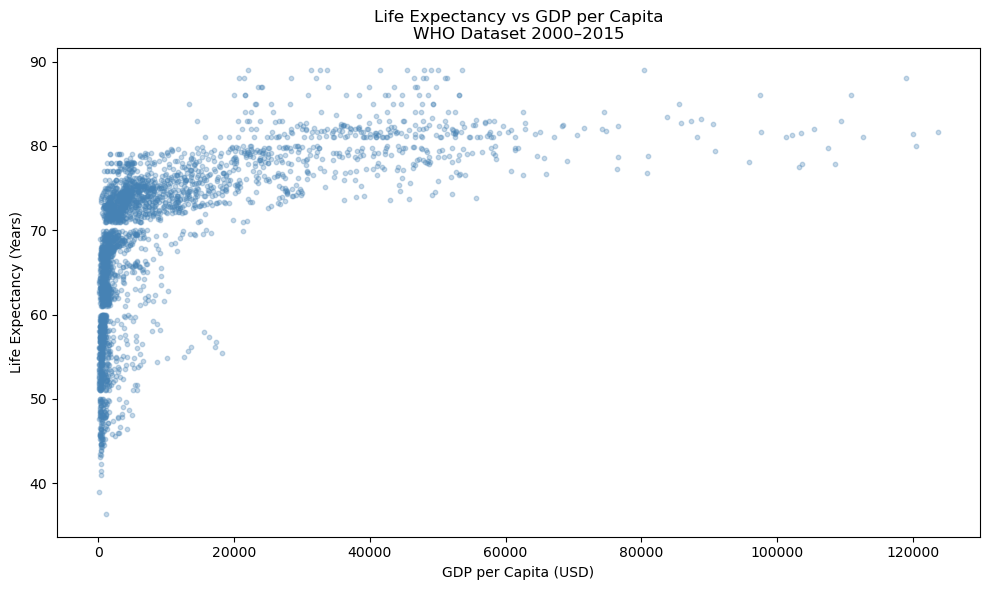

Chart saved.


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    who['GDP_per_capita'],
    who['Life expectancy'],
    alpha=0.3,
    s=10,
    color='steelblue'
)

ax.set_xlabel('GDP per Capita (USD)')
ax.set_ylabel('Life Expectancy (Years)')
ax.set_title('Life Expectancy vs GDP per Capita\nWHO Dataset 2000–2015')

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR_WHO, 'life_exp_vs_gdp.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")

In [5]:
print(who.columns.tolist())

['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling', 'Country Code', 'GDP_per_capita', 'Population', 'Region']


In [6]:
from scipy import stats

# ── Drop missing values for the two variables we're correlating ────
clean = who[['GDP_per_capita', 'Life expectancy']].dropna()

# ── Calculate correlation on log-transformed GDP ───────────────────
log_gdp = np.log10(clean['GDP_per_capita'])
r, p = stats.pearsonr(log_gdp, clean['Life expectancy'])

print(f"Pearson correlation (r):  {r:.3f}")
print(f"R² value:                 {r**2:.3f}")
print(f"P-value:                  {p:.2e}")

Pearson correlation (r):  0.784
R² value:                 0.615
P-value:                  0.00e+00


In [7]:
# ── Load suicide rates data ────────────────────────────────────────
SUICIDE_FILE = os.path.join(DATA_DIR, "suicide_rates_who.csv")
suicide = pd.read_csv(SUICIDE_FILE)

print("Shape:", suicide.shape)
print("\nColumns:")
print(suicide.columns.tolist())
print("\nFirst 5 rows:")
print(suicide.head().to_string())

Shape: (12210, 34)

Columns:
['IndicatorCode', 'Indicator', 'ValueType', 'ParentLocationCode', 'ParentLocation', 'Location type', 'SpatialDimValueCode', 'Location', 'Period type', 'Period', 'IsLatestYear', 'Dim1 type', 'Dim1', 'Dim1ValueCode', 'Dim2 type', 'Dim2', 'Dim2ValueCode', 'Dim3 type', 'Dim3', 'Dim3ValueCode', 'DataSourceDimValueCode', 'DataSource', 'FactValueNumericPrefix', 'FactValueNumeric', 'FactValueUoM', 'FactValueNumericLowPrefix', 'FactValueNumericLow', 'FactValueNumericHighPrefix', 'FactValueNumericHigh', 'Value', 'FactValueTranslationID', 'FactComments', 'Language', 'DateModified']

First 5 rows:
  IndicatorCode                                                Indicator ValueType ParentLocationCode         ParentLocation Location type SpatialDimValueCode                                                  Location Period type  Period  IsLatestYear Dim1 type        Dim1 Dim1ValueCode  Dim2 type  Dim2  Dim2ValueCode  Dim3 type  Dim3  Dim3ValueCode  DataSourceDimValueCode  Da

In [8]:
# ── Filter to Both sexes only and keep relevant columns ───────────
suicide_clean = suicide[suicide['Dim1'] == 'Both sexes'][
    ['Location', 'Period', 'FactValueNumeric']
].copy()

# ── Rename columns to something readable ──────────────────────────
suicide_clean = suicide_clean.rename(columns={
    'Location'         : 'Country',
    'Period'           : 'Year',
    'FactValueNumeric' : 'Suicide_Rate'
})

print("Shape:", suicide_clean.shape)
print("\nYear range:", suicide_clean['Year'].min(), "–", suicide_clean['Year'].max())
print("\nFirst 5 rows:")
print(suicide_clean.head().to_string())

Shape: (4070, 3)

Year range: 2000 – 2021

First 5 rows:
                             Country  Year  Suicide_Rate
3   Saint Vincent and the Grenadines  2021          0.29
16                            Jordan  2021          0.67
17                           Lebanon  2021          0.70
18              Syrian Arab Republic  2021          0.66
20                             Egypt  2021          0.73


In [9]:
# ── Check year distribution ────────────────────────────────────────
print("Rows per year:")
print(suicide_clean['Year'].value_counts().sort_index())

Rows per year:
Year
2000    185
2001    185
2002    185
2003    185
2004    185
2005    185
2006    185
2007    185
2008    185
2009    185
2010    185
2011    185
2012    185
2013    185
2014    185
2015    185
2016    185
2017    185
2018    185
2019    185
2020    185
2021    185
Name: count, dtype: int64


In [10]:
# ── Spot check some known values ───────────────────────────────────
check = ['United States', 'Japan', 'India', 'Brazil', 'Germany']
print(suicide_clean[
    (suicide_clean['Country'].isin(check)) &
    (suicide_clean['Year'] == 2015)
][['Country', 'Year', 'Suicide_Rate']].to_string())

      Country  Year  Suicide_Rate
3495    India  2015         15.17
3496    Japan  2015         15.21
3751   Brazil  2015          5.84
3863  Germany  2015          9.08


In [11]:
# ── Check country name mismatches ─────────────────────────────────
who_countries     = set(who['Country'].unique())
suicide_countries = set(suicide_clean['Country'].unique())

in_both           = who_countries & suicide_countries
in_who_only       = who_countries - suicide_countries
in_suicide_only   = suicide_countries - who_countries

print(f"Countries in both:          {len(in_both)}")
print(f"Countries in WHO only:      {len(in_who_only)}")
print(f"Countries in suicide only:  {len(in_suicide_only)}")

print(f"\nWHO only countries:")
print(sorted(in_who_only))

Countries in both:          162
Countries in WHO only:      31
Countries in suicide only:  23

WHO only countries:
['Bahamas, The', 'Bolivia', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Cook Islands', 'Dominica', 'Egypt, Arab Rep.', 'Gambia, The', 'Iran, Islamic Rep.', "Korea, Dem. People's Rep.", 'Korea, Rep.', 'Kyrgyz Republic', 'Lao PDR', 'Marshall Islands', 'Micronesia, Fed. Sts.', 'Moldova', 'Monaco', 'Nauru', 'Netherlands', 'Niue', 'Palau', 'Saint Kitts and Nevis', 'San Marino', 'Slovak Republic', 'Tanzania', 'Turkiye', 'Tuvalu', 'United Kingdom', 'United States', 'Venezuela, RB', 'Yemen, Rep.']


In [12]:
# ── Rename suicide countries to match WHO naming ───────────────────
suicide_clean['Country'] = suicide_clean['Country'].replace({
    'Bahamas'                          : 'Bahamas, The',
    'Bolivia (Plurinational State of)' : 'Bolivia',
    'Congo'                            : 'Congo, Rep.',
    'Democratic Republic of the Congo' : 'Congo, Dem. Rep.',
    "Côte d'Ivoire"                    : "Cote d'Ivoire",
    'Egypt'                            : 'Egypt, Arab Rep.',
    'Gambia'                           : 'Gambia, The',
    'Iran (Islamic Republic of)'       : 'Iran, Islamic Rep.',
    'Kyrgyzstan'                       : 'Kyrgyz Republic',
    "Lao People's Democratic Republic" : 'Lao PDR',
    'Micronesia (Federated States of)' : 'Micronesia, Fed. Sts.',
    'Republic of Korea'                : 'Korea, Rep.',
    'Republic of Moldova'              : 'Moldova',
    "Democratic People's Republic of Korea" : "Korea, Dem. People's Rep.",
    'Slovakia'                         : 'Slovak Republic',
    'Eswatini'                         : 'Eswatini',
    'North Macedonia'                  : 'North Macedonia',
    'Türkiye'                          : 'Turkiye',
    'United Kingdom of Great Britain and Northern Ireland' : 'United Kingdom',
    'United Republic of Tanzania'      : 'Tanzania',
    'United States of America'         : 'United States',
    'Venezuela (Bolivarian Republic of)' : 'Venezuela, RB',
    'Yemen'                            : 'Yemen, Rep.',
    'Netherlands (Kingdom of the)'     : 'Netherlands',
    'Viet Nam'                         : 'Viet Nam',
    'Monaco'                           : 'Monaco',
    'San Marino'                       : 'San Marino',
})

# ── Recheck ────────────────────────────────────────────────────────
who_countries     = set(who['Country'].unique())
suicide_countries = set(suicide_clean['Country'].unique())
in_who_only       = who_countries - suicide_countries

print(f"Remaining WHO only countries: {len(in_who_only)}")
print(sorted(in_who_only))

Remaining WHO only countries: 10
['Cook Islands', 'Dominica', 'Marshall Islands', 'Monaco', 'Nauru', 'Niue', 'Palau', 'Saint Kitts and Nevis', 'San Marino', 'Tuvalu']


In [13]:
# ── Check if remaining countries exist in suicide dataset at all ───
remaining = ['Cook Islands', 'Dominica', 'Marshall Islands', 'Monaco', 
             'Nauru', 'Niue', 'Palau', 'Saint Kitts and Nevis', 
             'San Marino', 'Tuvalu']

for country in remaining:
    match = suicide_clean[suicide_clean['Country'].str.contains(country, case=False)]
    if len(match) > 0:
        print(f"FOUND: {country} → {match['Country'].unique()}")
    else:
        print(f"NOT FOUND: {country}")

NOT FOUND: Cook Islands
FOUND: Dominica → ['Dominican Republic']
NOT FOUND: Marshall Islands
NOT FOUND: Monaco
NOT FOUND: Nauru
NOT FOUND: Niue
NOT FOUND: Palau
NOT FOUND: Saint Kitts and Nevis
NOT FOUND: San Marino
NOT FOUND: Tuvalu


In [14]:
# ── Merge suicide rates into WHO dataset ──────────────────────────
who = pd.merge(who,
               suicide_clean,
               on=['Country', 'Year'],
               how='left')

print("WHO shape after suicide merge:", who.shape)
print("Missing suicide rates:", who['Suicide_Rate'].isnull().sum())

WHO shape after suicide merge: (2938, 25)
Missing suicide rates: 10


In [15]:
# ── Spot check suicide rates ───────────────────────────────────────
check = ['Japan', 'India', 'United States', 'Brazil', 'Germany', 'Qatar']
print(who[
    (who['Country'].isin(check)) &
    (who['Year'] == 2015)
][['Country', 'GDP_per_capita', 'Suicide_Rate']].sort_values('Suicide_Rate', ascending=False).to_string())

            Country  GDP_per_capita  Suicide_Rate
1314          Japan    34960.639384         15.21
1186          India     1583.998159         15.17
2794  United States    56572.918900         12.82
994         Germany    41929.754911          9.08
2071          Qatar    68985.243338          6.14
352          Brazil     8936.195589          5.84


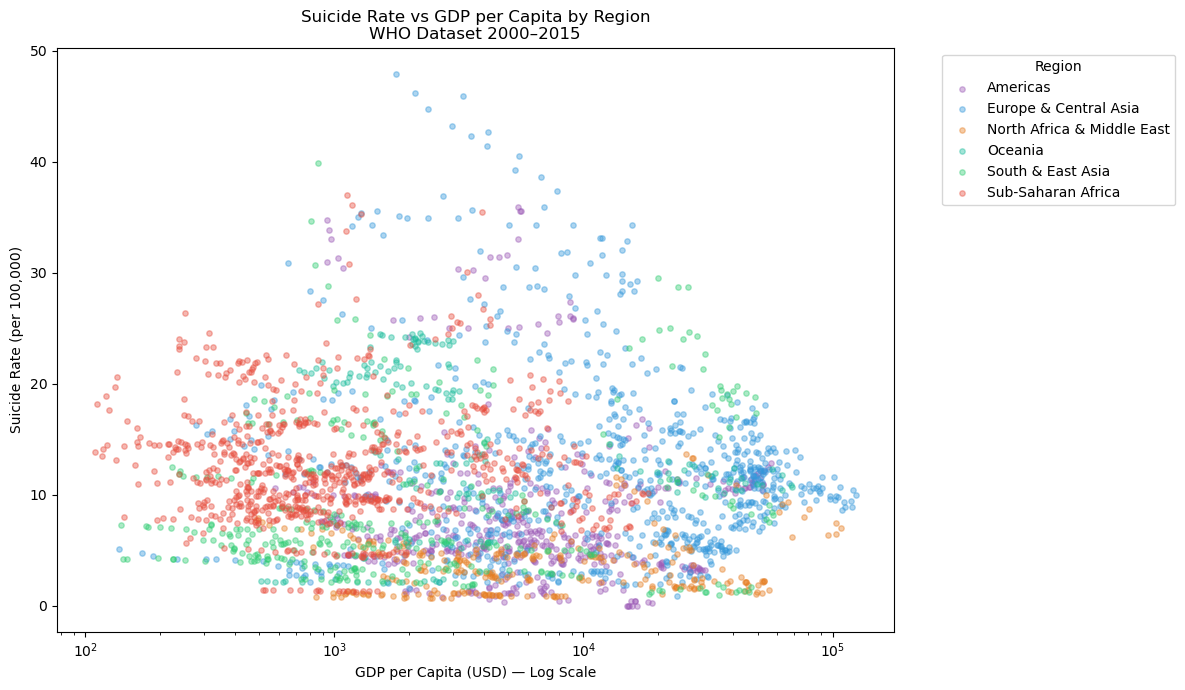

Chart saved.


In [16]:
# ── Scatter plot: GDP per capita vs Suicide Rate ───────────────────
fig, ax = plt.subplots(figsize=(12, 7))

for region, group in who.groupby('Region'):
    ax.scatter(
        group['GDP_per_capita'],
        group['Suicide_Rate'],
        label  = region,
        color  = region_colors[region],
        alpha  = 0.4,
        s      = 15
    )

ax.set_xscale('log')
ax.set_xlabel('GDP per Capita (USD) — Log Scale')
ax.set_ylabel('Suicide Rate (per 100,000)')
ax.set_title('Suicide Rate vs GDP per Capita by Region\nWHO Dataset 2000–2015')
ax.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR_WHO, 'suicide_vs_gdp_region.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")

## Hypothesis 2 — Conclusion

### Hypothesis Restated
Mental health outcomes follow a U-shaped curve relative to GDP per capita. At low wealth levels survival needs dominate but provide inherent meaning and purpose. Beyond a threshold of material comfort meaning becomes harder to find and mental health outcomes deteriorate.

**Proposed mechanism:** Frankl / logotherapy framework — survival as a source of meaning. Abundance removes existential drivers without replacing them.

---

### Finding — Indeterminate
H2 cannot be conclusively tested with available data. While the suicide rate vs GDP per capita chart suggests an inverted U pattern — rates peaking at middle income and declining at both extremes — this pattern cannot be reliably interpreted due to fundamental data limitations.

---

### Why the Data is Insufficient

**Proxy Problem**
Suicide rate is an imperfect proxy for mental health and an even more distant proxy for meaning and purpose. High suicide rates can result from poverty and despair, post-Soviet social collapse, agricultural debt crises, or any number of country-specific factors — not just existential meaninglessness.

**Underreporting**
Suicide is systematically underreported in Muslim-majority nations for religious and cultural reasons, artificially suppressing rates in North Africa & Middle East independently of underlying mental health reality.

**No Direct Mental Health Metric**
No direct measure of meaning, purpose, or mental health prevalence was available in the WHO dataset for 2000-2015 at country level granularity.

---

### What the Chart Shows
The suicide rate vs GDP per capita chart does not show the predicted U-shape. Rates appear highest at middle income levels and lower at both extremes. Given the confounds described above this pattern cannot be interpreted as evidence against the hypothesis.

---

### Path Forward — Hypothesis 3
H3 asks: Do highly religious countries show different suicide rate patterns relative to their wealth level compared to less religious countries?

This sidesteps theological complexity while directly testing whether meaning-making infrastructure moderates the wealth-mental health relationship.